Compare TNG result

In [10]:
import sys
sys.path.append('../Python_scripts')
from tqdm import tqdm

## Import packages
from config import *
from support import *
from cosmo_support import *

In [11]:
TNG=pd.read_excel('../Data/ZIjian_TNG.xlsx')
TNG.head()

,z,A,C0,sigma
0,0.1,0.047210,-13.170,2.5540
1,0.2,0.005693,-1.008,1.1180
2,0.3,0.003584,0.596,0.7043
3,0.4,0.002876,1.010,0.5158
4,0.5,0.002423,1.127,0.4306


In [12]:
def pdf_DM_cosmo1(Delta, C_0, A, sigma, alpha=3, beta=3):
    pdf=A*(Delta**(-beta))*np.exp(-((Delta**(-alpha)-C_0)**2)/(2*(alpha**2)*(sigma**2)))
    return pdf

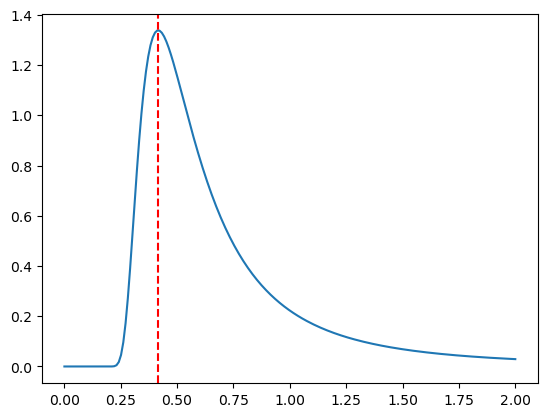

In [58]:
deltas=np.linspace(1e-36,2,200)
ps=np.zeros_like(deltas)
C0=-51
sigma=10
for i,d in enumerate(deltas):
    ps[i]=pdf_DM_cosmo1(d,C0,1,sigma,3,3)
    
plt.plot(deltas,ps)
plt.axvline(x=(2/(C0+np.sqrt(C0**2+36*sigma**2)))**(1/3), linestyle='--', color='r',label='mode')

In [43]:
def C0_sigma_median(sigma, x_min=0, alpha=3, beta=3):
    """
    Use fsolve to find C_0 when to_C_0 = 1
    
    Parameters:
    -----------
    F: float - Structure factor parameter 
    z: float - Redshift
    alpha: float - Alpha parameter
    initial_guess: float - C_0 initial guess
    
    Returns:
    --------
    float: C_0 or None if solution not found
    """
    
    def objective_function(C_0):
        
        A=10.0
        result,_= quad(lambda x: pdf_DM_cosmo(x, C_0, A, sigma, alpha, beta), x_min, 1.0)
        int,_=quad(lambda x: pdf_DM_cosmo(x, C_0, A, sigma, alpha, beta), 0, np.inf)
    
        return result-0.5*int

    try:
        initial_guess=1.0
        solution = fsolve(objective_function, [initial_guess], full_output=True)
        
        if solution[2] == 1:  # Check if solution is found
            return solution[0][0]
        else:
            print(f"find_C0 warning: sigma={sigma}")
            return None
            
    except Exception as e:
        print(f"find_C0 error, sigma={sigma}, error: {e}")
        return None

In [55]:
print(C0_sigma_median(0.01))

1.0003001804447558


In [48]:
def C0_sigma_mode(sigma, x_min=0, alpha=3, beta=3):
    """
    Use fsolve to find C_0 when to_C_0 = 1
    
    Parameters:
    -----------
    F: float - Structure factor parameter 
    z: float - Redshift
    alpha: float - Alpha parameter
    initial_guess: float - C_0 initial guess
    
    Returns:
    --------
    float: C_0 or None if solution not found
    """
    
    def objective_function(C_0):
        
        criteria=C_0**2+4*alpha*beta*sigma**2
        d3=2/(C_0+np.sqrt(criteria))
    
        return d3-1

    try:
        initial_guess=1.0
        solution = fsolve(objective_function, [initial_guess], full_output=True)
        
        if solution[2] == 1:  # Check if solution is found
            return solution[0][0]
        else:
            print(f"find_C0 warning: sigma={sigma}")
            return None
            
    except Exception as e:
        print(f"find_C0 error, sigma={sigma}, error: {e}")
        return None

In [ ]:
sigmas=np.linspace(0.01, 2.5, 50)
C0s=np.zeros_like(sigmas)
C0s_median=np.zeros_like(sigmas)
C0s_mode=np.zeros_like(sigmas)

for i, sigma in enumerate(sigmas):
    C0s[i]=C0_sigma(sigma)
    C0s_median[i]=C0_sigma_median(sigma)
    C0s_mode[i]=C0_sigma_mode(sigma)

Text(0, 0.5, 'C0')

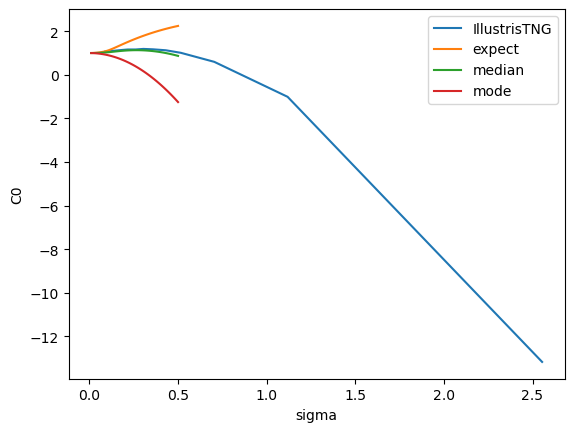

In [57]:
plt.plot(TNG['sigma'],TNG['C0'],label='IllustrisTNG')
plt.plot(sigmas,C0s,label='expect')
plt.plot(sigmas,C0s_median,label='median')
plt.plot(sigmas,C0s_mode,label='mode')
plt.legend()
plt.xlabel('sigma')
plt.ylabel('C0')

/mnt/d/Document/Research/FRB/cosmology/FRB_cosmology/code/../Python_scripts/cosmo_support.py:572: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.


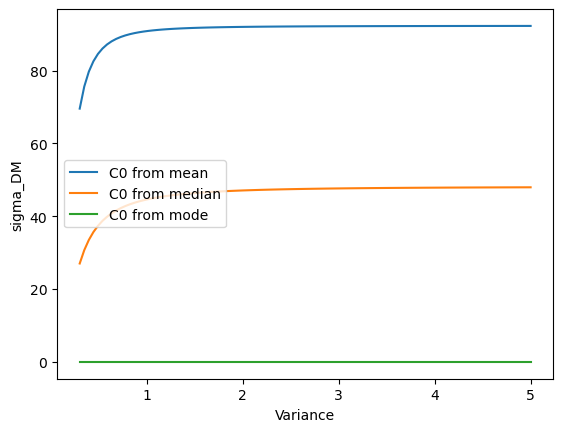

In [59]:
Sigmas=np.linspace(0.3, 5, 100)
Vars_mean=np.zeros_like(Sigmas)
Vars_median=np.zeros_like(Sigmas)
Vars_mode=np.zeros_like(Sigmas)

for i, sigma in enumerate(Sigmas):
    C01=C0_sigma(sigma)
    A1 = find_A_sigma(C_0=C01, sigma=sigma, alpha=3, beta=3)
    Vars_mean[i]=calculate_var(C0=C01, A=A1, sigma_DM=sigma)
    
    C02=C0_sigma_median(sigma)
    A2 = find_A_sigma(C_0=C02, sigma=sigma, alpha=3, beta=3)
    Vars_median[i]=calculate_var(C0=C02, A=A2, sigma_DM=sigma)
    
    C03=C0_sigma_mode(sigma)
    A3 = find_A_sigma(C_0=C03, sigma=sigma, alpha=3, beta=3)
    Vars_mean[i]=calculate_var(C0=C03, A=A3, sigma_DM=sigma)
    
plt.plot(Sigmas, Vars_mean, label='C0 from mean')
plt.plot(Sigmas, Vars_median, label='C0 from median')
plt.plot(Sigmas, Vars_mode, label='C0 from mode')
plt.ylabel('sigma_DM')
plt.xlabel('Variance')
plt.legend()

In [74]:
print(C0_sigma_median(10))

-51.59612846387587


/mnt/d/Document/Research/FRB/cosmology/FRB_cosmology/code/../Python_scripts/cosmo_support.py:522: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  second_moment, _ = quad(second_moment_integrand, x_min, x_max)


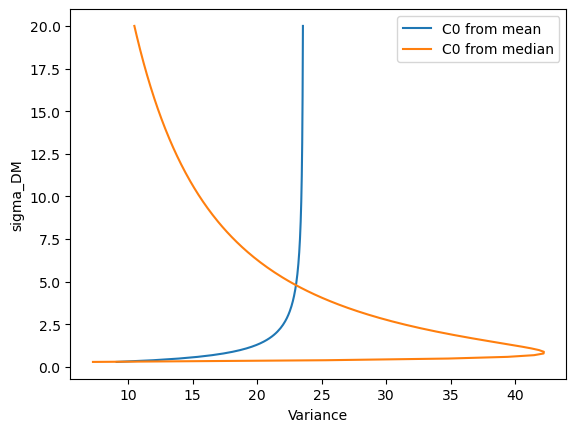

In [78]:
Sigmas=np.linspace(0.3, 20.0, 200)
Vars_mean=np.zeros_like(Sigmas)
Vars_median=np.zeros_like(Sigmas)
Vars_mode=np.zeros_like(Sigmas)

for i, sigma in enumerate(Sigmas):
    C01=C0_sigma(sigma)
    A1 = find_A_sigma(C_0=C01, sigma=sigma, alpha=3, beta=3)
    Vars_mean[i]=calculate_var(C0=C01, A=A1, sigma_DM=sigma)
    
    C02=C0_sigma_median(sigma)
    A2 = find_A_sigma(C_0=C02, sigma=sigma, alpha=3, beta=3)
    Vars_median[i]=calculate_var(C0=C02, A=A2, sigma_DM=sigma)
    
plt.plot(Vars_mean, Sigmas, label='C0 from mean')
plt.plot(Vars_median, Sigmas, label='C0 from median')
plt.ylabel('sigma_DM')
plt.xlabel('Variance')
plt.legend()